In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import seaborn as sns
from google.colab import drive
from google.colab import files
drive.mount('/content/drive')
data = pd.read_csv('/content/drive/My Drive/geyser.csv')
data

Mounted at /content/drive


,eruptions,waiting
0,3.600,79
1,1.800,54
2,3.333,74
3,2.283,62
4,4.533,85
...,...,...
267,4.117,81
268,2.150,46
269,4.417,90
270,1.817,46


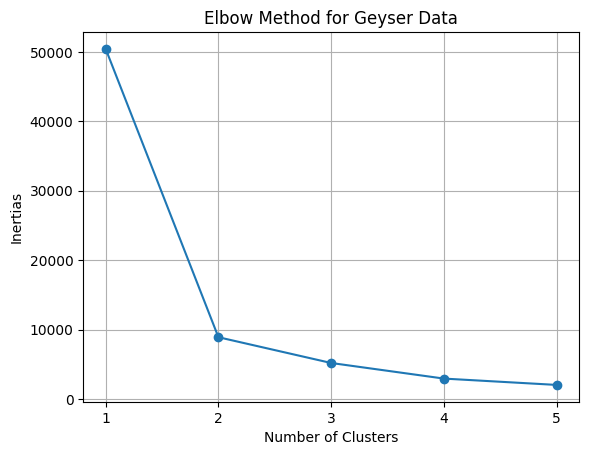

In [7]:
inertias = []
for cluster in clusters:
  kmeans = KMeans(n_clusters=cluster, random_state=0, n_init=5)
  kmeans.fit(data)
  inertias.append(kmeans.inertia_)

plt.plot(clusters, inertias, marker='o')
plt.xticks(clusters)
plt.xlabel("Number of Clusters")
plt.ylabel("Inertias")
plt.title("Elbow Method for Geyser Data")
plt.grid(True)
plt.show()

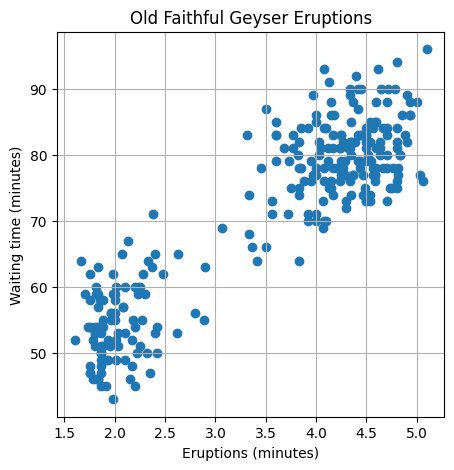

In [11]:
fig, ax = plt.subplots(figsize=(5,5))

ax.scatter(data["eruptions"], data["waiting"])
ax.set(xlabel='Eruptions (minutes)', ylabel='Waiting time (minutes)',
       title="Old Faithful Geyser Eruptions")
ax.grid()
plt.show()

In [12]:
kmeans = KMeans(n_clusters=2, random_state=0, n_init=5) # Using 2 as the optimal number of clusters
kmeans.fit(data)

KMeans(n_clusters=2, n_init=5, random_state=0)

In [ ]:
data["Cluster"] = kmeans.labels_

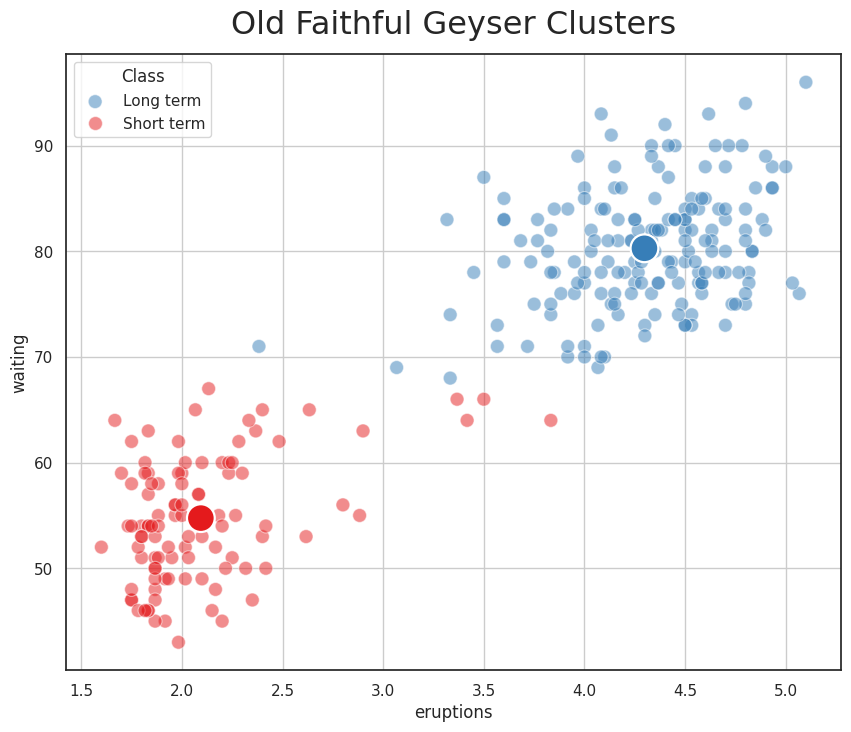

In [15]:
data["Cluster"] = kmeans.labels_ # Ensure 'Cluster' column exists
sns.set(rc = {'figure.figsize':(10,8)}, style="white", color_codes=True)

a = sns.scatterplot(x="eruptions", y="waiting", palette='Set1',
                    hue="Cluster", data=data, alpha=0.5, s=100)

label_index = []
for idx, label in enumerate(kmeans.cluster_centers_):
  label_index.append(idx)
scatter = sns.scatterplot(x=kmeans.cluster_centers_[:,0],y=kmeans.cluster_centers_[:,1],
                          palette='Set1', hue=label_index, s=400, legend=False)
scatter.set_title("Old Faithful Geyser Clusters", fontsize=23, y=1.02)
plt.legend(title='Class', loc='upper left', labels=['Long term', 'Short term'])
plt.grid(True)

In [14]:
print("Centroid coordinates:")
print(kmeans.cluster_centers_)

Centroid coordinates:
[[ 2.09433    54.75      ]
 [ 4.29793023 80.28488372]]
